mix them pixels yooo

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import linear_mixing as lmx

In [3]:
# Magic function to auto-update imported first-party scripts 
%load_ext autoreload
%autoreload 2

# other plotting

In [6]:
data = pd.read_csv("classification_results.csv")

In [ ]:
data.head()

In [ ]:
g = sns.catplot(
    data=data, kind="bar",
    x="Scheme", y="f1-score", hue="Sensor", 
    palette="dark", alpha=.6, height=6,
)
g.despine(left=True)
g.set(ylim = (0.5, 1))
g.set_axis_labels("Classification scheme", " F1 score")
g.legend.set_title("")
g.savefig(r"C:\Users\s4770224\Documents\Work\Writing\Figures\Obj1\part2\class_sensor_scores.svg")

# mixing pixels

In [4]:
material_options = {
    "kelp" : ['ecklonia', 'macrocystis', 'undaria'],
    # "brown_algae" : ['ecklonia', 'macrocystis', 'petalonia', 
    #                  'undaria','acrocarpia', 'cystophora', 'carpophyllum', 'durvillaea', 'hormosira', 'phyllospora', 'sargassum', 'scytosiphon'], 
    "brown_non_kelp" : ['acrocarpia', 'cystophora', 'carpophyllum', 
                         'durvillaea', 'hormosira', 'petalonia','phyllospora', 'sargassum', 'scytosiphon'],
    "red_veg" : ['rhodophyte', 'filamentous_rhodophyte','frondose_rhodophyte',],
    "green_veg" : ['grass', 'ulva'],
    # "non_brown_autos" : ['grass', 'filamentous_rhodophyte',
    #                      'frondose_rhodophyte', 'rhodophyte', 'ulva'],
    # "all_non_kelp_autos" : ['acrocarpia', 'carpophyllum', 'cystophora', 
    #                         'durvillaea', 'filamentous_rhodophyte','frondose_rhodophyte', 'petalonia', 'grass','hormosira','phyllospora', 'rhodophyte',  'sargassum','scytosiphon','ulva'],
    # "all_non_kelp" : ['acrocarpia', 'barnacle_shells', 'carpophyllum',
    #                   'cystophora', 'durvillaea', 'filamentous_rhodophyte','frondose_rhodophyte', 'gravel', 'grass','hormosira','mussels','petalonia','phyllospora', 'rhodophyte', 'rock','sand', 'sargassum', 'scytosiphon', 'shell_litter','rock', 'ulva', 'worm_castings'],
    "mineral" : ['barnacle_shells', 'gravel', 'mussels', 'rock', 'sand', 
                  'shell_litter', 'worm_castings'],
    }
material_options.keys()

dict_keys(['kelp', 'brown_non_kelp', 'red_veg', 'green_veg', 'mineral'])

In [62]:
#Assign fractional cover ranges with simulate within
cover_ranges = {
    "kelp" : (0,0.8),
    #"brown_algae" : (0, 0.5), 
    "brown_non_kelp" : (0,0.8),
    "red_veg" : (0,0.2),
    "green_veg" : (0, 0.5),
    #"non_brown_autos" : (0, 40),
    #"all_non_kelp_autos" : (0, 100),
    #"all_non_kelp" : (0,100),
    "mineral" : (0,0.7),}

In [6]:
data = pd.read_csv("./data/processed/resampled/noisy_Sentinel_2_ABC_resampled.csv", index_col=0)
labels = pd.read_csv("data/labels_prepped.csv", index_col=0)
data = pd.concat([labels["Class"], data], axis = 1)

In [63]:
waters = pd.read_csv("./S2_deep_water_agg.csv", index_col=0)
waters = waters.iloc[:, 4:-3]
print(f"total of {waters.shape[0]} water pixels loaded")
waters.drop_duplicates(inplace = True)
print(f"Total of {waters.shape[0]} unique water pixels kept")
waters= waters/10000
waters.head()


total of 400637 water pixels loaded
Total of 393022 unique water pixels kept


,nbart_blue,nbart_green,nbart_red,nbart_red_edge_1,nbart_red_edge_2,nbart_red_edge_3,nbart_nir_1,nbart_nir_2
1,0.0323,0.0327,0.0163,0.0168,0.0187,0.0195,0.0203,0.0198
2,0.0327,0.0303,0.0162,0.0177,0.0199,0.0210,0.0182,0.0217
3,0.0309,0.0310,0.0174,0.0177,0.0199,0.0210,0.0193,0.0217
4,0.0316,0.0329,0.0181,0.0192,0.0195,0.0211,0.0192,0.0208
6,0.0344,0.0319,0.0200,0.0192,0.0195,0.0211,0.0218,0.0208


In [69]:
mixer = lmx.LinearMixing(materials = material_options, cover_ranges = cover_ranges, pixels = 100000, material_spectra= data, water_spectra = waters)


In [70]:
results, f = mixer.sim_many_pixels()

In [75]:
simulated_pixels, pixel_fpcs = mixer.format_sim_results(results, f)
simulated_pixels.head()

,S2A_SR_AV_B2,S2A_SR_AV_B3,S2A_SR_AV_B4,S2A_SR_AV_B5,S2A_SR_AV_B6,S2A_SR_AV_B7,S2A_SR_AV_B8,S2A_SR_AV_B8A
0,0.029212,0.044331,0.032225,0.070038,0.131837,0.139524,0.139305,0.141538
1,0.029252,0.051453,0.028750,0.139985,0.278811,0.300098,0.309642,0.317397
2,0.021293,0.146385,0.086087,0.477330,0.789428,0.852040,0.851231,0.841373
3,0.018785,0.019416,0.010183,0.059535,0.240373,0.266207,0.271250,0.275085
4,0.052132,0.077876,0.044381,0.100340,0.224121,0.235653,0.234135,0.238042


In [76]:
pixel_fpcs.head()

,kelp,brown_non_kelp,red_veg,green_veg,mineral,water,non-water_comps
0,0.000000,0.000000,0.000000,0.148956,0.0,0.851044,1
1,0.000000,0.216442,0.118795,0.000000,0.0,0.664763,2
2,0.191885,0.594437,0.009786,0.096248,0.0,0.107644,4
3,0.000000,0.253981,0.020894,0.000000,0.0,0.725125,2
4,0.000000,0.000000,0.000000,0.234943,0.0,0.765057,1


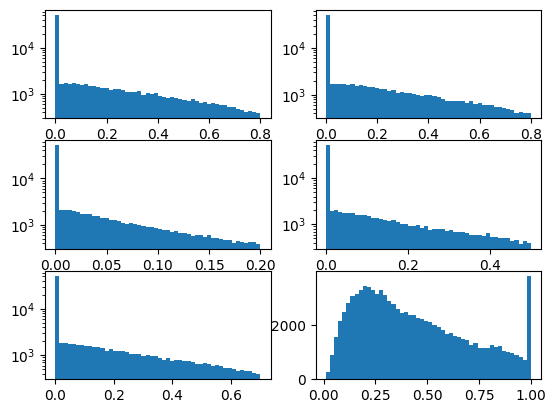

In [77]:
# Plot the components of the simulated pixels

args = {'log' : True} 

fig, ax = plt.subplots(3,2)
ax[0,0].hist(pixel_fpcs['kelp'], bins = 50,range = (0.00000000000, max(pixel_fpcs['kelp'])), **args) #log = True)
ax[0,1].hist(pixel_fpcs['brown_non_kelp'], bins = 50, range = (0.00000000000, max(pixel_fpcs['brown_non_kelp'])), **args)
ax[1,0].hist(pixel_fpcs['red_veg'], bins = 50, range = (0.00000000000, max(pixel_fpcs['red_veg'])), **args)
ax[1,1].hist(pixel_fpcs['green_veg'], bins = 50, range = (0.00000000000, max(pixel_fpcs['green_veg'])), **args)
ax[2,0].hist(pixel_fpcs['mineral'], bins = 50, range = (0.00000000000, max(pixel_fpcs['mineral'])), **args)
ax[2,1].hist(pixel_fpcs['water'], bins = 50)

fig.savefig(r"C:\Users\s4770224\Documents\Work\Writing\Figures\Obj1\part2\simulated_pixel_fpcs_histograms.svg")
plt.show()

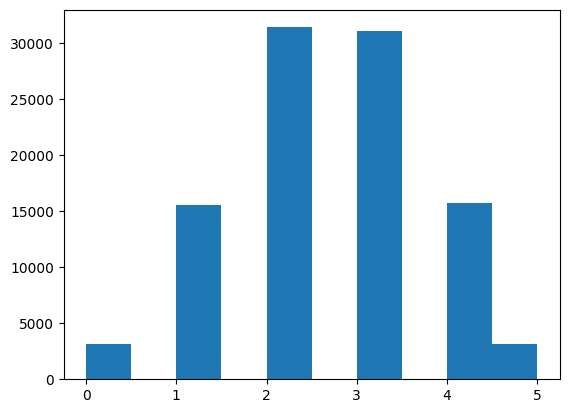

In [79]:
plt.hist(pixel_fpcs['non-water_comps'])
fig.savefig(r"C:\Users\s4770224\Documents\Work\Writing\Figures\Obj1\part2\simulated_pixel_component_counts.svg")
plt.show()

In [80]:
simulated_pixels.to_csv("data/mixed_sims/kbrgm_simulated_pixels.csv")
pixel_fpcs.to_csv("data/mixed_sims/kbrgm_pixel_fpcs.csv")

In [84]:
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

In [141]:
# Add water to classifier training set 
sample_idx = np.random.choice(waters.index, size = 100, replace = False)
water_sample = waters.iloc[sample_idx, :]
water_sample.columns = data.columns[1:]
data_watered = pd.concat([data, water_sample], axis = 0, )
water_labels = pd.DataFrame("water", index = sample_idx, columns = labels.columns)
labels_watered = pd.concat([labels, water_labels], axis = 0)

In [142]:
data_watered

,Class,S2A_SR_AV_B2,S2A_SR_AV_B3,S2A_SR_AV_B4,S2A_SR_AV_B5,S2A_SR_AV_B6,S2A_SR_AV_B7,S2A_SR_AV_B8,S2A_SR_AV_B8A
244,undaria,0.005206,0.035179,0.017558,0.402000,0.982698,0.975532,0.938330,0.919465
246,undaria,0.005957,0.044634,0.020618,0.424736,0.983955,0.973723,0.918249,0.881488
291,undaria,0.011551,0.097328,0.042814,0.553741,0.949986,0.958648,0.969237,0.958401
290,undaria,0.010566,0.091353,0.037172,0.533386,0.953627,0.961981,0.964234,0.946394
289,undaria,0.014887,0.117873,0.063220,0.591136,0.957582,0.959564,0.967193,0.954576
...,...,...,...,...,...,...,...,...,...
4271,NaN,0.041300,0.037400,0.021900,0.020100,0.019600,0.019100,0.018900,0.019700
46637,NaN,0.016800,0.014000,0.006700,0.005600,0.005600,0.007000,0.004500,0.004700
35780,NaN,0.012700,0.007100,0.002300,0.002900,0.003700,0.003700,0.002100,0.004600
8432,NaN,0.051800,0.046800,0.039500,0.040400,0.042400,0.041000,0.040700,0.037900


In [143]:
classer = RandomForestClassifier(random_state=4)
classer.fit(data_watered.iloc[:, 1:], labels_watered["kbrgm"])

RandomForestClassifier(random_state=4)

In [144]:
pred = pd.DataFrame(classer.predict(simulated_pixels))

In [145]:
maj_sim = pd.DataFrame(pixel_fpcs.columns[np.argmax(pixel_fpcs.iloc[:, :-1].values, axis = 1)])

In [146]:
print(f"{sum(pred == maj_sim)} out of {len(pred)} correct classifications")

0 out of 100000 correct classifications


In [147]:
pixel_results = pd.concat([pixel_fpcs, maj_sim, pred], axis = 1)
pixel_results.to_csv("data/mixed_sims/kbrgm_pixel_class_results_2.csv")